In [2]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import sqlite3

### 1. Import Data & SQL connection

In [3]:
conn = sqlite3.connect('customer_churn.db')

sql_query = """
    SELECT name from sqlite_master WHERE type='table';
"""

tables = pd.read_sql_query(sql_query, conn)

# create dataframe for each table
for table_name in tables['name']:
    df = pd.read_sql(f"select * from {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"Dataframe for table '{table_name}' created as 'df_{table_name}'")


conn.close()


Dataframe for table 'db_customer' created as 'df_db_customer'
Dataframe for table 'db_subscription' created as 'df_db_subscription'
Dataframe for table 'db_support' created as 'df_db_support'


In [4]:
# Print table names columns names
conn = sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
    print(f"\nTable: {table_name}")
    # get column information
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print("Columns:")
    print(columns['name'].tolist())


conn.close()


Table: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


### 2. Data Cleaning

#### df_db_customer

In [5]:
df_db_customer.head()
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,None,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,None,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,None,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,None,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,None,None


In [6]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


- df_db_customer :-
    - a. Rename col -> name
    - b. Drop column = interests, pincode
    - c. change datatype for dob = object -> date
    - d. data standardization - gender  
    - e. fix missing value for country column

In [7]:
# a. Rename col -> name
df_db_customer.rename(columns = {'name' : 'customer_name'}, inplace = True)
df_db_customer

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00,None,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,None,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,None,None
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00,None,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,None,None


In [8]:
# b. Drop column = interests, pincode
# Drop by index method
# df_db_customer.columns[-2:]    # Index(['interests', 'pincode'], dtype='object')
# df_db_customer.drop(df_db_customer.columns[-2:], axis = 1)
# df_db_customer.drop(df_db_customer.columns[6:], axis = 1)

# by column name method
df_db_customer.drop(columns = ['interests', 'pincode'], axis = 1, inplace = True)

In [9]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerid     21 non-null     object
 1   customer_name  21 non-null     object
 2   country        18 non-null     object
 3   state          21 non-null     object
 4   gender         21 non-null     object
 5   dob            21 non-null     object
dtypes: object(6)
memory usage: 1.1+ KB


In [10]:
# c. change datatype for dob = object -> datetime

df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [11]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     object        
 1   customer_name  21 non-null     object        
 2   country        18 non-null     object        
 3   state          21 non-null     object        
 4   gender         21 non-null     object        
 5   dob            21 non-null     datetime64[ns]
dtypes: datetime64[ns](1), object(5)
memory usage: 1.1+ KB


In [12]:
# d. data standardization - gender 

df_db_customer['gender'].unique()

array(['Male', 'Female', 'Women', 'Men'], dtype=object)

In [13]:
# Using 'replace' method to standardize the gender values like Men -> Male, Women -> Female
df_db_customer['gender'].replace({'Men': 'Male', 'Women': 'Female'}, inplace = True)

C:\Users\91911\AppData\Local\Temp\ipykernel_19344\791547383.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_db_customer['gender'].replace({'Men': 'Male', 'Women': 'Female'}, inplace = True)


In [14]:
df_db_customer['gender'].unique()

array(['Male', 'Female'], dtype=object)

In [15]:
# e. fix missing value for country column

df_db_customer['country'].isna().sum()

3

In [16]:
# to show the rows with missing values in country column
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01


In [17]:
# Method 1 : Fill manually with a specific value like 'Delhi' to fill the missing values in country column to India, in kathmandu to Nepal like this
# Method 2 : Find the pair present in the dataset and fill the missing values in country column based on the pair present in the dataset. For example, if city = 'Delhi' then country = 'India', if city = 'Kathmandu' then country = 'Nepal' and so on.

In [18]:
df_db_customer[['country', 'state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,None,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,None,Kathmandu
9,Nepal,Kathmandu


In [19]:
# country and state pairs - unique values pair
state_country_mapping = df_db_customer.dropna(subset = ['country']).set_index('state')['country'].to_dict() 

df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping), inplace = True)


C:\Users\91911\AppData\Local\Temp\ipykernel_19344\1739849610.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping), inplace = True)


In [20]:
df_db_customer['country']

0     India
1     India
2     India
3     India
4     India
5     India
6     India
7     India
8     Nepal
9     Nepal
10    India
11    India
12    India
13    India
14    India
15    India
16    India
17    India
18    India
19    India
20    India
Name: country, dtype: object

In [21]:
df_db_customer['country'].isna().sum()

0

In [22]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


#### db_subscription

In [23]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [24]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [25]:
# all the date columns are object type, we need to convert them to datetime type for further analysis

date_col = ['subscription_start_date', 'renewal_date', 'cancellation_date']
df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime, errors = 'coerce')
df_db_subscription[date_col].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   subscription_start_date  21 non-null     datetime64[ns]
 1   renewal_date             21 non-null     datetime64[ns]
 2   cancellation_date        6 non-null      datetime64[ns]
dtypes: datetime64[ns](3)
memory usage: 636.0 bytes


#### df_db_support

In [26]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [27]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


In [28]:
# there is no requriment of col_1 , comment columns

df_db_support.drop(columns = ['col_1', 'comment'], inplace = True)

In [29]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'], errors = 'coerce')
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      object        
 3   csat_score      9 non-null      int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 420.0+ bytes


### 3. Feature Engineering & Data Analysis

In [30]:
# creating a new column churn_flag in df_db_subscription to indicate whether a customer has churned or not. If the cancellation_date is not null, it means the customer has churned, so we assign a value of 1 to churn_flag. Otherwise, we assign a value of 0.
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notnull(), 1, 0)
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [31]:
# join the table 

df = df_db_subscription.merge(df_db_customer, on = 'customerid', how = 'left').merge(df_db_support, on = 'customerid', how = 'left')

In [32]:
df.shape

(23, 20)

In [33]:
df_db_subscription.shape

(21, 12)

- there is 2 more extra row are comes, means there is some fault after join

In [34]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,N,60.0
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN


- 0003-MKNFE this customerid comes 2

In [35]:
df_db_subscription['customerid'].nunique()

21

In [36]:
df_db_customer['customerid'].nunique()

21

In [37]:
df_db_support['customerid'].nunique()

7

In [38]:
df_db_support['customerid'].size    # here is the fault, support table has multiple rows for the same customerid, so we need to drop the duplicate rows based on customerid column in df_db_support table before merging it with other tables. We can use drop_duplicates() method to drop the duplicate rows based on customerid column in df_db_support table.

9

In [39]:
df_db_support

# index 0 and 7 customerid are duplicate rows, we can drop the duplicate rows based on customerid column in df_db_support table using drop_duplicates() method.

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [40]:
# groupby method to find the duplicate rows based on customerid column in df_db_support table
df_db_support['complaint_count']=df_db_support.groupby('customerid')['customerid'].transform('count')

In [41]:
# now i will only store the latest data for each customerid in df_db_support table, so i will sort the df_db_support table based on complaint_date column in descending order and then drop the duplicate rows based on customerid column in df_db_support table using drop_duplicates() method.
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates(subset = 'customerid', keep = 'last')

In [42]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
2,0013-EXCHZ,2024-01-20,Y,20,1
5,0017-IUDMW,2024-04-10,Y,25,1
1,0003-MKNFE,2024-08-28,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2
6,0019-EFAEP,2024-09-27,Y,30,1
4,0013-SMEOE,2024-11-01,N,30,1
3,0013-MHZWF,2025-03-18,N,90,1


In [43]:
df_db_support['customerid'].size

7

In [44]:
 # now i will do the merge operation again after dropping the duplicate rows in df_db_support table based on customerid column.
df = df_db_subscription.merge(df_db_customer, on = 'customerid', how = 'left').merge(df_db_support, on = 'customerid', how = 'left')

In [45]:
df.shape

(21, 21)

In [46]:
df.to_csv('exported_churn_data.csv', index = False)

### 3.2 Analysis

#### 1. Chrun Rate


In [47]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [48]:
chrun_rate = df['churn_flag'].mean()*100
print(f"Chrun Rate: {chrun_rate:.2f}%")

Chrun Rate: 28.57%


#### 2. Retenion Rate

In [49]:
retension_rate = 100 - chrun_rate
print(f"Retention Rate: {retension_rate:.2f}%")

Retention Rate: 71.43%


#### 3. Churn by plan typr

In [50]:
# Now I want know which type of user leave the service more, so I will do the analysis based on plan_type
churn_by_plan_type = df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name = 'churn_rate_pct')
print(churn_by_plan_type)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


#### 4.a. Churn by state + sum of revenu and count of users
#### 4.b. Churn by subscription type + sum of revenu and count of users

#### 5. ARPU : Average Revenue per user

In [51]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [52]:
arpu = df['monthly_charges'].mean()
print(f"Average Revenue Per User: {arpu:.2f}")

Average Revenue Per User: 18.85


#### 6. Avg Customer Tenure
- Count of days user has used our service : use cancellation date otherwise use current date

In [53]:
today = pd.to_datetime('today')
df['tenure_days'] = np.where(
    df['cancellation_date'].notna(), 
        (df['cancellation_date'] - df['subscription_start_date']).dt.days, 
        (today - df['subscription_start_date']).dt.days
)

avg_tenure = df['tenure_days'].mean()
print(f"Average Tenure: {round(avg_tenure)} days")

Average Tenure: 1514 days


#### 7. Revenue at risk - Revenue lost from churned users

In [54]:
revenue_at_risk = df.loc[df['churn_flag'] == 1, 'monthly_charges'].sum()
print(f"Revenue at Risk: {revenue_at_risk:.2f} K")

Revenue at Risk: 73.94 K


#### 8. Esclation Rate : 

In [55]:
df['escalations'].unique()

array([nan, 'Y', 'N'], dtype=object)

In [56]:
escalations_rate = (df['escalations'] == "Y").mean()*100
print(f"Escalations Rate: {escalations_rate:.2f}%")

Escalations Rate: 19.05%


#### 9. Average Complaint per user

In [57]:
avg_compalaints = df['complaint_count'].sum() / df['customer_name'].nunique()
print(f"Average Number of Complaints: {avg_compalaints:.2f}")

Average Number of Complaints: 0.43


#### 10. Correlation Esclation VS Churn

In [58]:
# encoding 'escalations' data to 1 and 0, like 'Yes' -> 1, 'No' -> 0
df['escalations'] = np.where(df['escalations'] == 'Y', 1, 0)
corr_df = df[['escalations', 'churn_flag']].dropna()

correlation = corr_df['escalations'].corr(corr_df['churn_flag'])
print(f"Correlation between escalations and churn_flag: {correlation:.2f}")

Correlation between escalations and churn_flag: 0.77


#### 11. Churn Risk -> Create a column using existing column


In [59]:
df['churn_score'].head()

0    12
1    91
2    34
3     8
4    88
Name: churn_score, dtype: int64

In [60]:
condition =[
    (df['churn_score'] < 50) ,
    (df['churn_score'] >= 50) &  (df['churn_score'] < 70),
    (df['churn_score'] >= 70) 
]
choices = ['Low Risk', 'Medium Risk', 'High Risk']

df['churn_risk'] = np.select(condition, choices, default = 'Unknown')


In [61]:
df[['churn_score', 'churn_risk']].head()

,churn_score,churn_risk
0,12,Low Risk
1,91,High Risk
2,34,Low Risk
3,8,Low Risk
4,88,High Risk


# 4. Visualization using matplotlib

In [62]:
df_visual = df.copy()

In [63]:
df_visual.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,1974.0,Low Risk
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501.0,High Risk
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,India,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,1359.0,Low Risk
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,India,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,2649.0,Low Risk
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,India,Delhi,Female,1990-05-05,2024-01-20,1,20.0,1.0,419.0,High Risk


In [64]:
df_visual.shape

(21, 23)

In [65]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='object')

#### 4.1 Monthly Churn Trend(Time Series KPI)

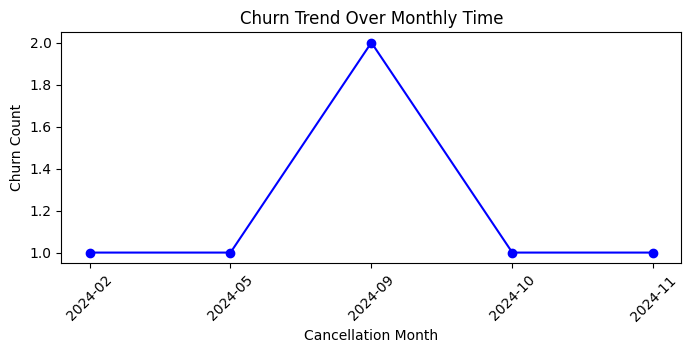

In [66]:
df_visual['cancellation_month'] = df['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()

plt.figure(figsize = (8, 3))
plt.plot(churn_trend.index.astype(str), churn_trend.values, marker = 'o', linestyle = '-', color = 'blue')
plt.title('Churn Trend Over Monthly Time')
plt.xlabel('Cancellation Month')
plt.ylabel('Churn Count')
plt.xticks(rotation = 45)
plt.show()

### 4.2 Churn by Plan Type

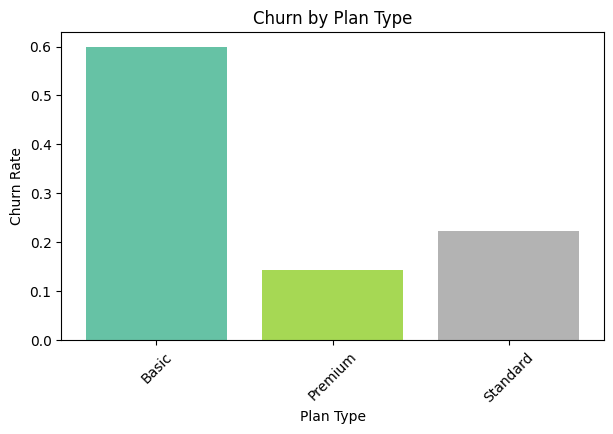

In [74]:
churn_plan =  df_visual.groupby('plan_type')['churn_flag'].mean()
plt.figure(figsize = (7, 4))
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))
plt.bar(churn_plan.index, churn_plan.values, color = colors)
plt.title('Churn by Plan Type')
plt.xlabel('Plan Type')
plt.ylabel('Churn Rate')
plt.xticks(rotation = 45)
plt.show()

#### 4.3 Churn by State

In [75]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

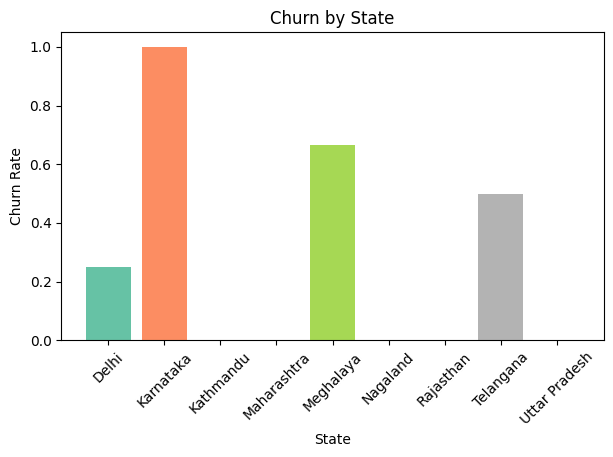

In [77]:
churn_state = df_visual.groupby('state')['churn_flag'].mean()
plt.figure(figsize = (7, 4))
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_state)))
plt.bar(churn_state.index, churn_state.values, color = colors)
plt.title('Churn by State')
plt.xlabel('State')
plt.ylabel('Churn Rate')
plt.xticks(rotation = 45)
plt.show()

# Visualization Using Seaborn

In [ ]:
# Heatmap (correlation matrix) to visualize the correlation between numerical features in the dataset. This can help identify potential relationships between variables and churn.

sns.heatmap(df_visual.corr(), annot = True)

ValueError: could not convert string to float: '0002-ORFBO'

- for using the heatmap, we need to convert the categorical variables into numerical variables using one-hot encoding or label encoding. For example, we can use pd.get_dummies() method to convert the categorical variables into numerical variables.
-  Encoding :- Convert string to numerical values for categorical features like gender, plan_type, so that we can find corr between the features.

In [79]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [84]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# This is in-correct method of encoding( how we encode high to 0, medium to 2, low 1, this is not correct way ) as number are not assigned based on priority
df_encoded = df[['plan_type', 'contract_type','churn_score','churn_flag','churn_risk', 'escalations']]

categorical_cols = ['plan_type', 'contract_type', 'churn_risk'] 
for col in categorical_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,2,0,12,0,1,0
1,1,0,91,1,0,1
2,0,1,34,0,1,0
3,1,0,8,0,1,0
4,2,1,88,1,0,1


<Axes: >

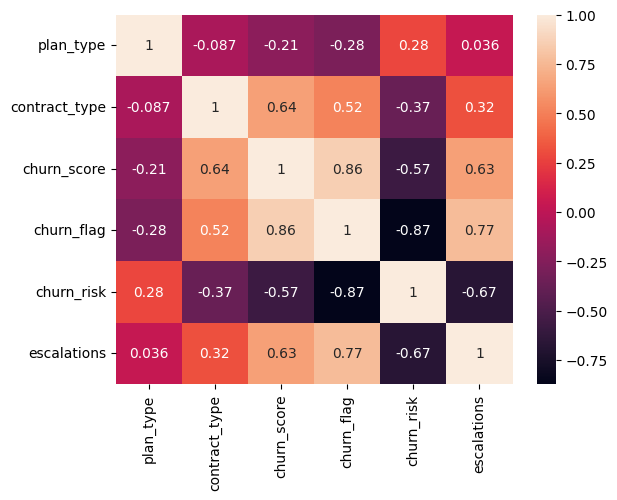

In [ ]:
# Now we buld heatmap
sns.heatmap(df_encoded.corr(), annot = True)


* 0 to 1 -> +ve Correlation
* -1 to 0 -> -ve Correaltion

In [89]:
df_visual['plan_type'].unique()

array(['Standard', 'Premium', 'Basic'], dtype=object)

In [90]:
df_visual['contract_type'].unique()

array(['Annual', 'Monthly'], dtype=object)

In [91]:
df_visual['churn_risk'].unique()

array(['Low Risk', 'High Risk', 'Medium Risk'], dtype=object)

In [ ]:
# correct method of encoding based on priority
df_encoded = df[['plan_type', 'contract_type','churn_score','churn_flag','churn_risk', 'escalations']]

order_mapping = {
    'plan_type': ['Basic', 'Standard', 'Premium'] ,
    'contract_type' : [ 'Monthly', 'Annual'],
    'churn_risk' : ['Low Risk', 'High Risk', 'Medium Risk']
}
for col, order in order_mapping.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories= order, ordered = True).codes


,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,1,1
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,1,1


In [97]:
df_visual[['plan_type', 'contract_type','churn_score','churn_flag','churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,Low Risk,0
1,Premium,Annual,91,1,High Risk,1
2,Basic,Monthly,34,0,Low Risk,0
3,Premium,Annual,8,0,Low Risk,0
4,Standard,Monthly,88,1,High Risk,1


In [94]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,1,1
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,1,1


<Axes: >

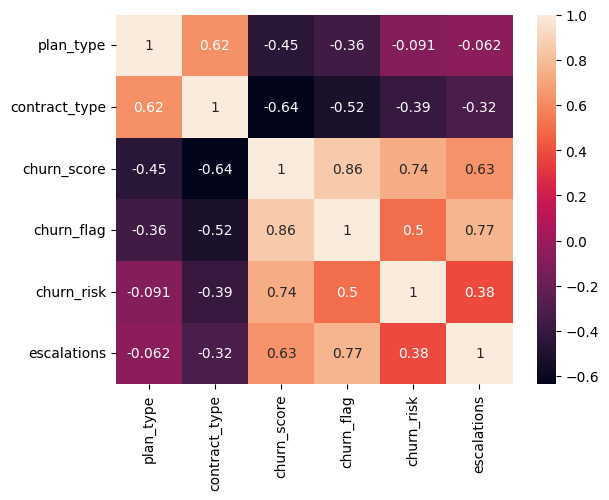

In [98]:
# Now we buld heatmap
sns.heatmap(df_encoded.corr(), annot = True)


#### Pair plot 
- Relationship in a dataset

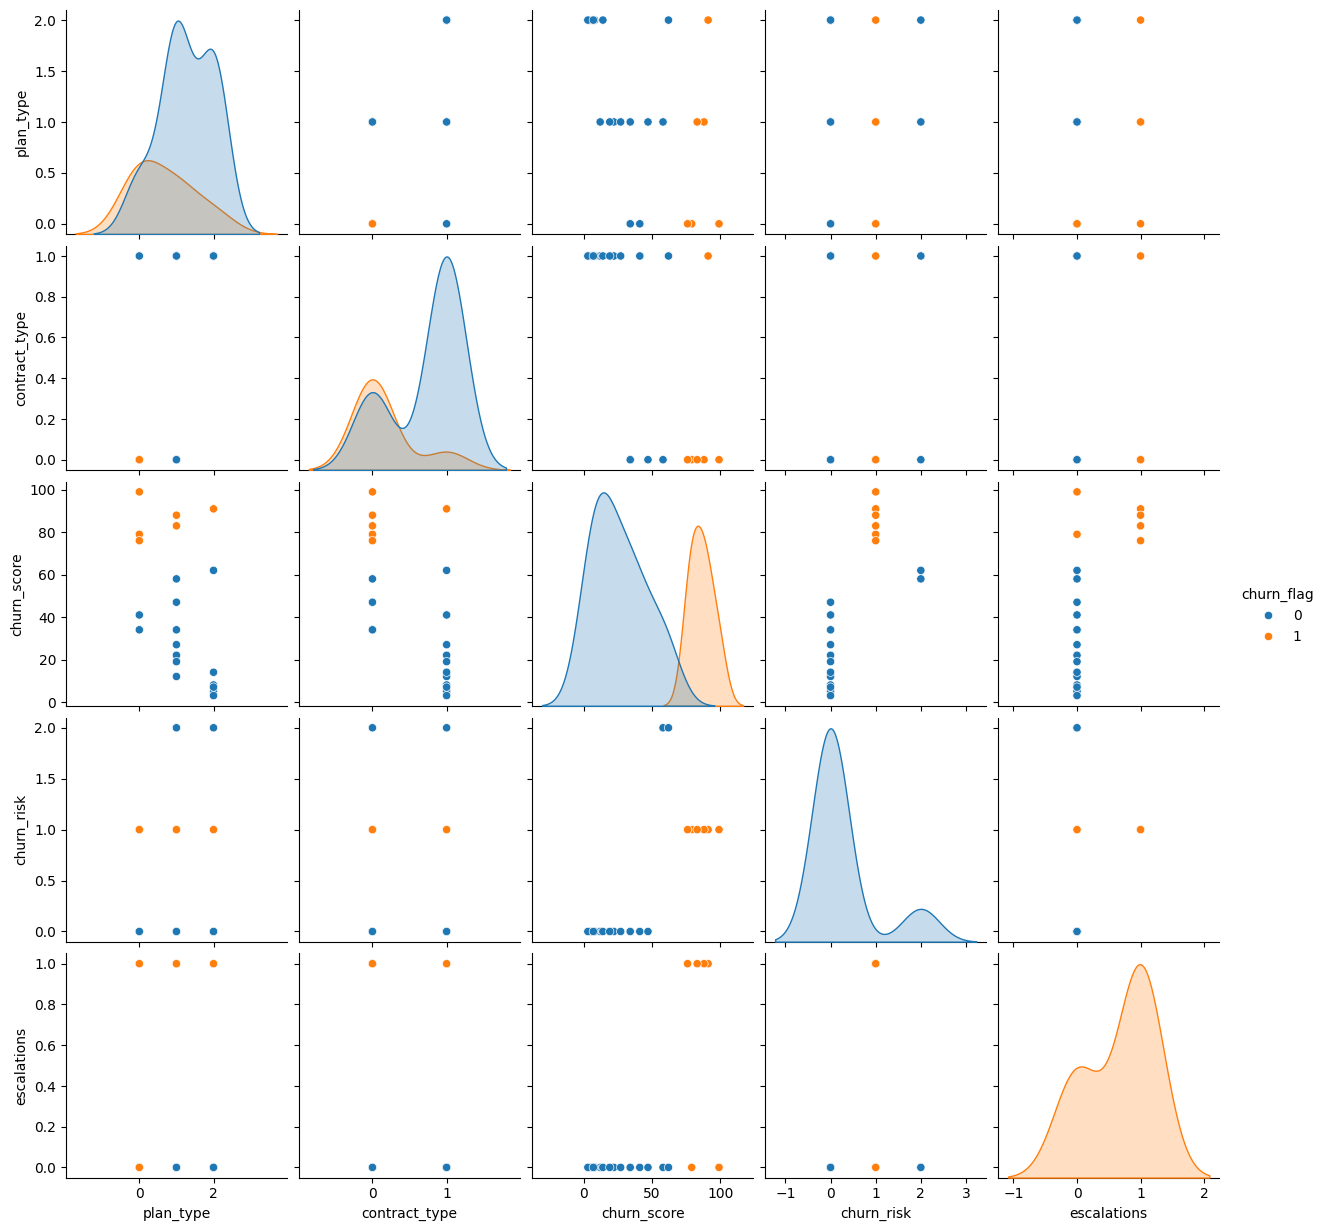

In [99]:
sns.pairplot(df_encoded, hue = 'churn_flag')

#### catplt/Facegrid plot
- Multi-dim comparison

In [100]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

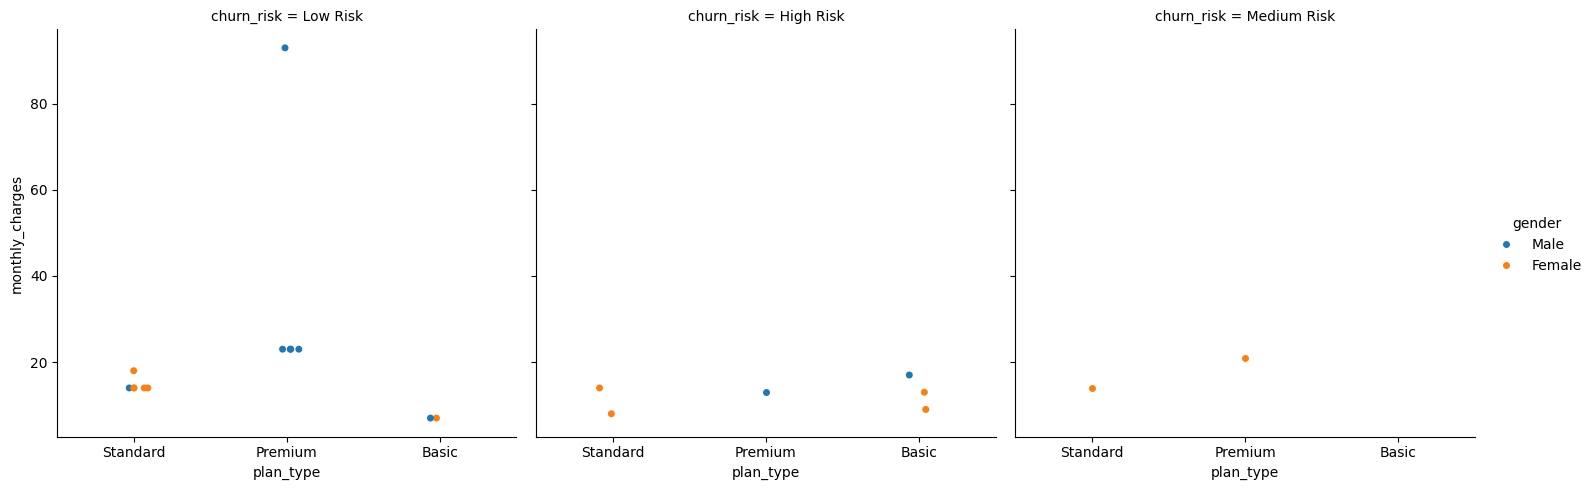

In [102]:
sns.catplot(data=df_visual, 
            x= 'plan_type',
            y = 'monthly_charges',
            hue= 'gender',
            col= 'churn_risk')

# 5. Pivot Table

In [103]:
pd.pivot_table(
    df_visual,
    values = 'churn_flag',
    index = 'plan_type',
    aggfunc = 'mean'
)

,churn_flag
plan_type,
Basic,0.600000
Premium,0.142857
Standard,0.222222


In [104]:
pd.pivot_table(
    df_visual,
    values = 'churn_flag',
    index = 'plan_type',
    aggfunc = 'mean'
).reset_index()

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [105]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [107]:
pd.pivot_table(
    df_visual,
    index = 'plan_type',
    values = ['monthly_charges','customerid', 'churn_flag' ],
    aggfunc = {
        'monthly_charges' : 'sum',
        'customerid' : 'count',
        'churn_flag' : 'mean'   ,
    }
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


# Working with SQL in Python(pandas)

In [108]:
# Create a database in SQL
conn = sqlite3.connect('test_database.sqlite')

In [110]:
# table details
conn.execute("CREATE table users (first_name TEXT, country TEXT, budget INTEGER)")

#commit and save
conn.commit()

In [ ]:
# Insert data
cursor = conn.cursor()
# write SQL query to insert values
cursor.execute(
    """
        INSERT INTO users VALUES
            ('John', 'USA', 1000),
            ('Jane', 'USA', 2000),
            ('Mark', 'Canada', 3000),
            ('Mary', 'Canada', 4000),
            ('Bob', 'USA', 5000)
        
    """
)

conn.commit()
print("Data inserted successfully") 
 

In [116]:
# How to check data from table
conn = sqlite3.connect('test_database.sqlite')
query = """select * from users"""
df_result = pd.read_sql(query, conn)
print(df_result)

  first_name country  budget
0       John     USA    1000
1       Jane     USA    2000
2       Mark  Canada    3000
3       Mary  Canada    4000
4        Bob     USA    5000


In [117]:
# Aggregation
query = """
    select country, sum(budget) as total_budget from users group by country order by total_budget desc    
"""
df_aggry_result = pd.read_sql(query, conn)
df_aggry_result.head()

,country,total_budget
0,USA,8000
1,Canada,7000


In [ ]:
# Always close the connection after use it to avoid memory leak issues.
conn.close()